In [1]:
import gc
import xarray as xr
import numpy as np
from shapely.geometry import Point, LineString, MultiLineString
from shapely.ops import polygonize
from pyproj import CRS
import pandas as pd
import geopandas as gpd
from scipy import interpolate

#### CRSs ####
WGS84 = CRS('epsg:4326')  # WGS84
ETRS89UTM = CRS('epsg:25834') # ETRS89 / UTM zone 34N

In [2]:
# %%
# create grid (as polygons) for calculating density rasters
#
def create_grid(res=0.1,lon1=None,lon2=None,lat1=None,lat2=None,save=False):
    print('creating a grid with the resolution of {} degrees'.format(res))

    # setting boundaries for study area
    latmin = 59.81651
    latmax = 63.44978
    lonmin = 17.05540
    lonmax = 22.33311
    # coordinates for the grid to be made
    x = np.arange(lonmin, lonmax+res, res)
    y = np.arange(latmin, latmax+res, res)
    # taking only the extent set by lon1,lon2,lat1,lat2
    if lon1 is not None:
        x = x[x>lon1]
    if lon2 is not None:
        x = x[x<lon2]
    if lat1 is not None:
        y = y[y>lat1]
    if lat2 is not None:
        y = y[y<lat2]
    # get grid dimensions X,Y
    X = len(x)
    Y = len(y)
    # create horisontal and vertical lines
    hlines = [((x1, yi), (x2, yi)) for x1, x2 in zip(x[:-1], x[1:]) for yi in y]
    vlines = [((xi, y1), (xi, y2)) for y1, y2 in zip(y[:-1], y[1:]) for xi in x]
    # construct grid using the lines
    grids = list(polygonize(MultiLineString(hlines + vlines)))
    grid = gpd.GeoDataFrame(grids,columns=['geometry'])
    #grid.set_geometry('geometry',drop=True,inplace=True)
    grid.crs = WGS84
    # set id for each grid point
    grid['gridid'] = grid.index+1
    # set the grid point centre coordinates
    lon = x[:-1]+res/2
    lat = y[:-1]+res/2
    lons,lats = np.meshgrid(lon,lat)
    lons,lats = np.meshgrid(np.round(lon,6),np.round(lat,6)) 
    if save:
        grid['c_lon'] = lons.T.flatten()
        grid['c_lat'] = lats.T.flatten()
    else:
        grid['c_coords'] = list(zip(lons.T.flatten(),lats.T.flatten()))
        grid['c_coords'] = grid['c_coords'].apply(Point)

    return grid

In [3]:
# %%
# saving grid created with create_grid()
#
def save_grid(grid,fname):
    ext = fname.split('.')[-1]
    if ext == 'shp':
        driver = 'ESRI Shapefile'
    elif ext == 'gpkg':
        driver = 'GPKG'
    else:
        logging.error('file format {} not supported')
        return False

    try:
        grid.to_file(filename=fname, driver=driver)
    except:
        return False
    return True

In [4]:
# %%
# load grid for calculating density rasters
#
def load_grid(fname,lon1=None,lon2=None,lat1=None,lat2=None):
    # load file
    grid = gpd.read_file(fname)
    # take only the extent set with lon1,lon2,lat1,lat2
    if lon1 is not None:
        bounds = grid.geometry.bounds
        rows = bounds.minx>lon1
        grid = grid[rows]
    if lon2 is not None:
        bounds = grid.geometry.bounds
        rows = bounds.maxx<lon2
        grid = grid[rows]
    if lat1 is not None:
        bounds = grid.geometry.bounds
        rows = bounds.miny>lat1
        grid = grid[rows]
    if lat2 is not None:
        bounds = grid.geometry.bounds
        rows = bounds.maxy<lat2
        grid = grid[rows]
    # transform grid centre coordinates into Point
    grid['c_coords'] = list(zip(grid['c_lon'],grid['c_lat']))
    grid['c_coords'] = grid['c_coords'].apply(Point)
    # and drop the original columns
    grid.drop(columns=['c_lon','c_lat'],inplace=True)
    # rearrange columns and return grid
    return grid[['c_coords','gridid','geometry']]

In [5]:
res1 = 0.1
grid1 = create_grid(res=res1,lon1=None,lon2=None,lat1=None,lat2=None,save=False)
#save_grid(grid1,'test_grid_{}.gpkg'.format(res1))

res2 = 0.05
grid2 = create_grid(res=res2,lon1=None,lon2=None,lat1=None,lat2=None,save=False)
#save_grid(grid2,'test_grid_{}.gpkg'.format(res2))

creating a grid with the resolution of 0.1 degrees
creating a grid with the resolution of 0.05 degrees


(61.0, 62.0)

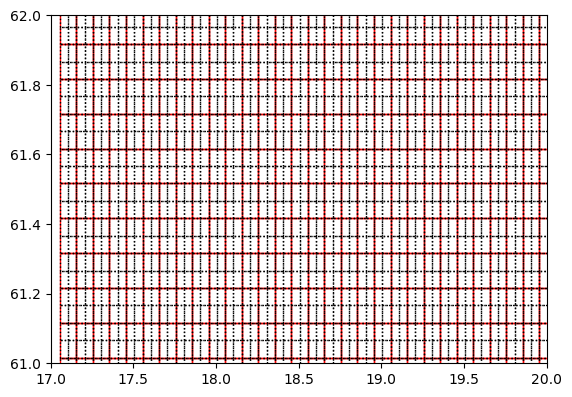

In [6]:
import matplotlib.pyplot as plt
fig,ax = plt.subplots(1,1)
grid1.plot(facecolor='none',edgecolor='r',ax=ax)
grid2.plot(facecolor='none',linestyle=':',ax=ax)
ax.set_xlim(17.0,20.0)
ax.set_ylim(61.0,62.0)